Dataset:
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

Final Hypothesis:
Sky = Sunny
AirTemp = Warm
Humidity = ?
Wind = Strong
Water = ?
Forecast = ?


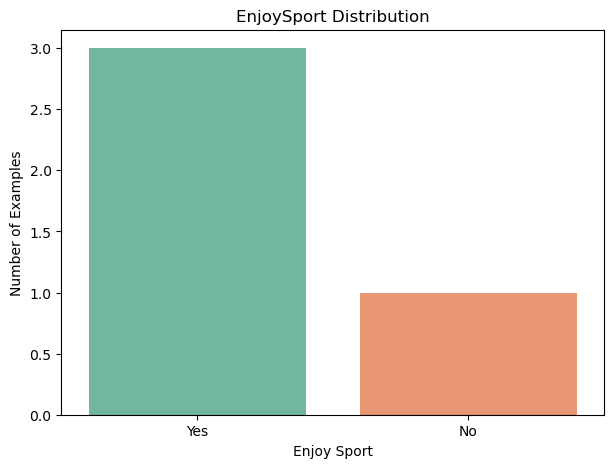

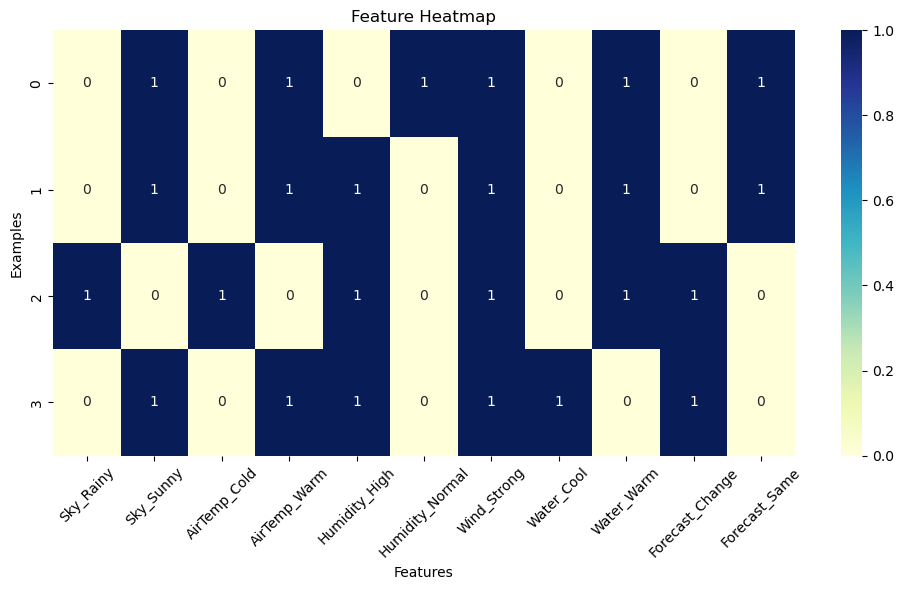

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.DataFrame({
    "Sky": ["Sunny", "Sunny", "Rainy", "Sunny"],
    "AirTemp": ["Warm", "Warm", "Cold", "Warm"],
    "Humidity": ["Normal", "High", "High", "High"],
    "Wind": ["Strong", "Strong", "Strong", "Strong"],
    "Water": ["Warm", "Warm", "Warm", "Cool"],
    "Forecast": ["Same", "Same", "Change", "Change"],
    "EnjoySport": ["Yes", "Yes", "No", "Yes"]
})

print("Dataset:")
print(data)

def find_s(data, target):
    attributes = [col for col in data.columns if col != target]
    positive = data[data[target] == "Yes"]

    hypothesis = list(positive.iloc[0][attributes])

    for _, example in positive.iloc[1:].iterrows():
        for i in range(len(attributes)):
            if hypothesis[i] != example[attributes[i]]:
                hypothesis[i] = "?"

    return dict(zip(attributes, hypothesis))

hypothesis = find_s(data, "EnjoySport")

print("\nFinal Hypothesis:")
for attribute, value in hypothesis.items():
    print(attribute, "=", value)

plt.figure(figsize=(7, 5))
sns.countplot(x="EnjoySport", data=data, hue="EnjoySport", palette="Set2", legend=False)
plt.title("EnjoySport Distribution")
plt.xlabel("Enjoy Sport")
plt.ylabel("Number of Examples")
plt.show()

encoded_data = pd.get_dummies(data.drop("EnjoySport", axis=1)).astype(int)

plt.figure(figsize=(10, 6))
sns.heatmap(encoded_data, annot=True, cmap="YlGnBu", cbar=True)
plt.title("Feature Heatmap")
plt.xlabel("Features")
plt.ylabel("Examples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

DATASET
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

FIND-S HYPOTHESIS EVALUATION

H1
Sky = Sunny
AirTemp = Warm
Humidity = Normal
Wind = Strong
Water = Warm
Forecast = Same

H2
Sky = Sunny
AirTemp = Warm
Humidity = ?
Wind = Strong
Water = Warm
Forecast = Same

H3
Sky = Sunny
AirTemp = Warm
Humidity = ?
Wind = Strong
Water = ?
Forecast = ?

HYPOTHESIS EVALUATION
  Hypothesis  Specific  Generalized (?)
0         H1         6                0
1         H2         5                1
2         H3         3                3


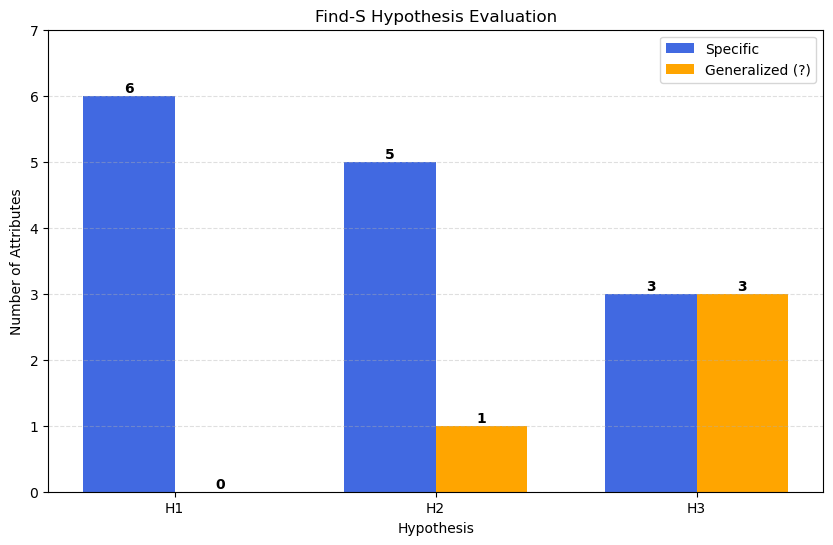

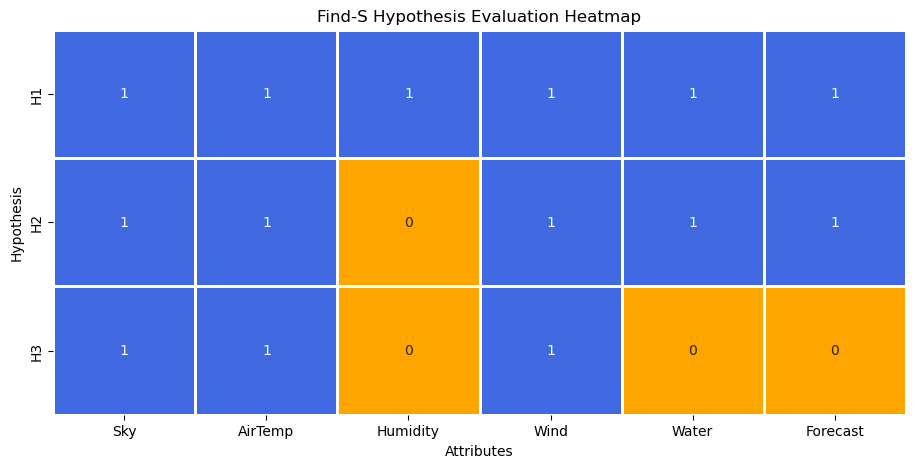


FINAL HYPOTHESIS
Sky = Sunny
AirTemp = Warm
Humidity = ?
Wind = Strong
Water = ?
Forecast = ?


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.DataFrame({
    "Sky": ["Sunny", "Sunny", "Rainy", "Sunny"],
    "AirTemp": ["Warm", "Warm", "Cold", "Warm"],
    "Humidity": ["Normal", "High", "High", "High"],
    "Wind": ["Strong", "Strong", "Strong", "Strong"],
    "Water": ["Warm", "Warm", "Warm", "Cool"],
    "Forecast": ["Same", "Same", "Change", "Change"],
    "EnjoySport": ["Yes", "Yes", "No", "Yes"]
})

print("DATASET")
print(data)

attributes = list(data.columns[:-1])
positive_examples = data[data["EnjoySport"] == "Yes"]

hypothesis = ["0"] * len(attributes)
hypotheses = []

for _, example in positive_examples.iterrows():

    if hypothesis == ["0"] * len(attributes):
        hypothesis = list(example[attributes])
    else:
        for i in range(len(attributes)):
            if hypothesis[i] != example[attributes[i]]:
                hypothesis[i] = "?"

    hypotheses.append(hypothesis.copy())

hypothesis_names = [f"H{i}" for i in range(1, len(hypotheses) + 1)]

print("\nFIND-S HYPOTHESIS")

for name, h in zip(hypothesis_names, hypotheses):
    print(name, "=", dict(zip(attributes, h)))

specific_count = []
question_count = []

for h in hypotheses:
    specific_count.append(sum(value != "?" for value in h))
    question_count.append(sum(value == "?" for value in h))

evaluation = pd.DataFrame({
    "Hypothesis": hypothesis_names,
    "Specific": specific_count,
    "?": question_count
})

print("\nHYPOTHESIS EVALUATION")
print(evaluation)

plt.figure(figsize=(10, 6))

x = range(len(hypothesis_names))
width = 0.35

bars1 = plt.bar(
    [i - width / 2 for i in x],
    specific_count,
    width,
    color="royalblue",
    label="Specific Values"
)

bars2 = plt.bar(
    [i + width / 2 for i in x],
    question_count,
    width,
    color="orange",
    label="? Values"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        str(int(bar.get_height())),
        ha="center",
        fontweight="bold"
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        str(int(bar.get_height())),
        ha="center",
        fontweight="bold"
    )

plt.xticks(x, hypothesis_names)
plt.xlabel("Hypothesis")
plt.ylabel("Number of Attributes")
plt.title("Find-S Hypothesis Evaluation: Specific vs ?")
plt.legend()
plt.ylim(0, len(attributes) + 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

heatmap_values = []

for h in hypotheses:
    row = []

    for value in h:
        if value == "?":
            row.append(0)
        else:
            row.append(1)

    heatmap_values.append(row)

heatmap_data = pd.DataFrame(
    heatmap_values,
    columns=attributes,
    index=hypothesis_names
)

plt.figure(figsize=(12, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap=["orange", "royalblue"],
    linewidths=1,
    linecolor="white",
    cbar=False
)

plt.title("Find-S Hypothesis Heatmap")
plt.xlabel("Attributes")
plt.ylabel("Hypothesis")
plt.show()

print("\nFINAL HYPOTHESIS")

for attribute, value in zip(attributes, hypotheses[-1]):
    print(attribute, "=", value)|
    